In [62]:
import pandas as pd
import numpy as np
from plotnine import *
import statsmodels.formula.api as smf
import statsmodels.api as sm
from sklearn.decomposition import PCA

### Section 01 - Linear regression for Predicting Heights

In [63]:
heights = pd.read_csv("height.csv",
usecols=['height', 'sex', 'mother', 'father']).dropna()
heights['sex'] = heights['sex'].str.upper()
heights.loc[heights['sex'] == 'W', 'sex'] = 'F'
print(heights)

     height sex  mother  father
0       150   F   170.0   177.0
1       152   F   157.0   175.0
2       152   F   155.0   156.0
3       153   F   155.0   175.0
4       153   F   150.0   176.0
..      ...  ..     ...     ...
553     197   M   183.0   190.0
554     197   M   175.0   189.0
555     197   M   163.0   192.0
556     204   M   180.0   184.0
557     173   M   155.0   180.0

[545 rows x 4 columns]


1. Let’s focus on one sex. Fit a linear model for each male’s height given the father’s height. Then, fit
another linear model for the father’s height given each male’s height.

In [64]:
import statsmodels.formula.api as sm

males = heights[heights['sex'] == 'M']

print('Model 1: height ~ father')
fit1 = sm.ols('height ~ father', data = males).fit()
print(fit1.summary2().tables[1])

(ggplot(males, aes(x='father', y='height'))
+ geom_point(alpha=0.5)
+ geom_smooth(method='lm', color='blue')
+ theme(figure_size=(3, 1.5))
).draw()

print('Model 2: father ~ height')
fit2 = sm.ols('father ~ height', data = males).fit()
print(fit2.summary2().tables[1])


Model 1: height ~ father
               Coef.  Std.Err.          t         P>|t|     [0.025      0.975]
Intercept  93.983299  8.403878  11.183325  2.507584e-24  77.442003  110.524596
father      0.488549  0.047318  10.324824  1.895175e-21   0.395413    0.581684
Model 2: father ~ height
               Coef.  Std.Err.          t         P>|t|     [0.025     0.975]
Intercept  77.024150  9.733204   7.913545  5.530516e-14  57.866351  96.181949
height      0.555783  0.053830  10.324824  1.895175e-21   0.449830   0.661736


2. Predict each male student’s height given the father’s height (predict()) and predict each father’s
height given each male student’s height. Store both predictions into new columns of a data table. Then,
plot the original data and additionally both regression lines. Hint: use geom_line

In [65]:
males["predicted_student_height"] = fit1.predict(males)
males["predicted_father_height"] = fit2.predict(males)
males

/tmp/ipykernel_69242/2705380277.py:1: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
/tmp/ipykernel_69242/2705380277.py:2: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy


,height,sex,mother,father,predicted_student_height,predicted_father_height
10,155,M,170.0,173.0,178.502205,163.170479
69,163,M,150.0,168.0,176.059462,167.616741
82,163,M,155.0,162.0,173.128170,167.616741
111,164,M,161.0,193.0,188.273176,168.172524
124,165,M,157.0,178.0,180.944947,168.728307
...,...,...,...,...,...,...
553,197,M,183.0,190.0,186.807531,186.513355
554,197,M,175.0,189.0,186.318982,186.513355
555,197,M,163.0,192.0,187.784628,186.513355
556,204,M,180.0,184.0,183.876239,190.403835


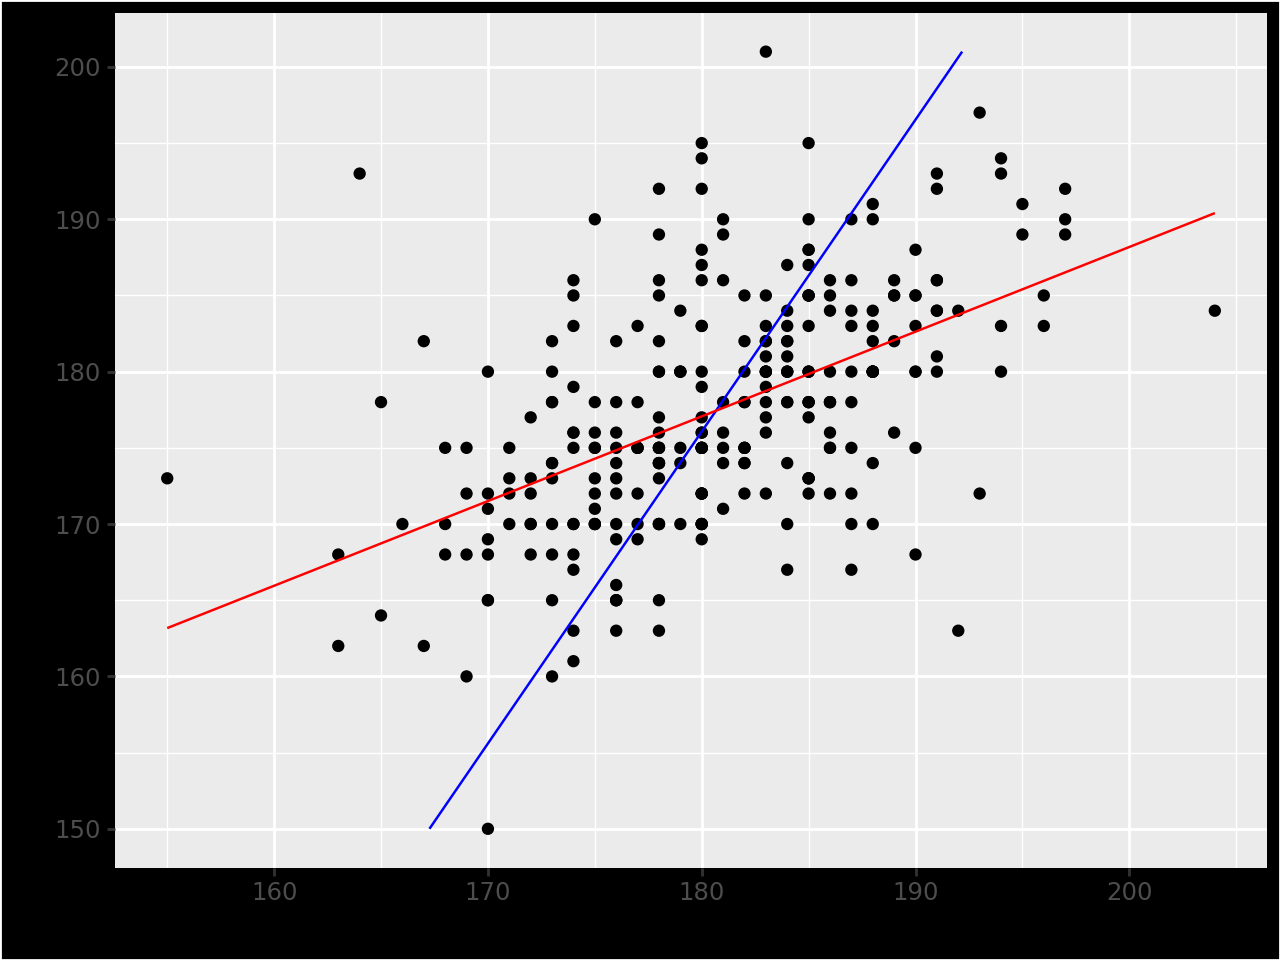

In [66]:
ggplot(males, aes(x = 'height', y = 'father')) + geom_point() + geom_line(aes(x = 'predicted_student_height', y = 'father'), color="blue") + geom_line(aes(x = 'height', y = 'predicted_father_height'), color="red")

3. Additionally, run a PCA on the same subset of the data and plot the first principal component line
into the same figure. Hint: you can get the unit vector of the first principal component by accessing
the components_ attribute of the object obtained from PCA. Given this unit vector compute the slope
and intercept and use geom_abline to plot the resulting line. Remember that the slope, 𝑚, of a line
can be calculated from the coordinates (𝑢𝑥
, 𝑢𝑦
) of its unit vector, 𝑚 = 𝑢𝑦 / 𝑢𝑥
and recall that the principal
component line contains the center of the data. Use geom_abline to plot the line from the computed
intercept and slope.

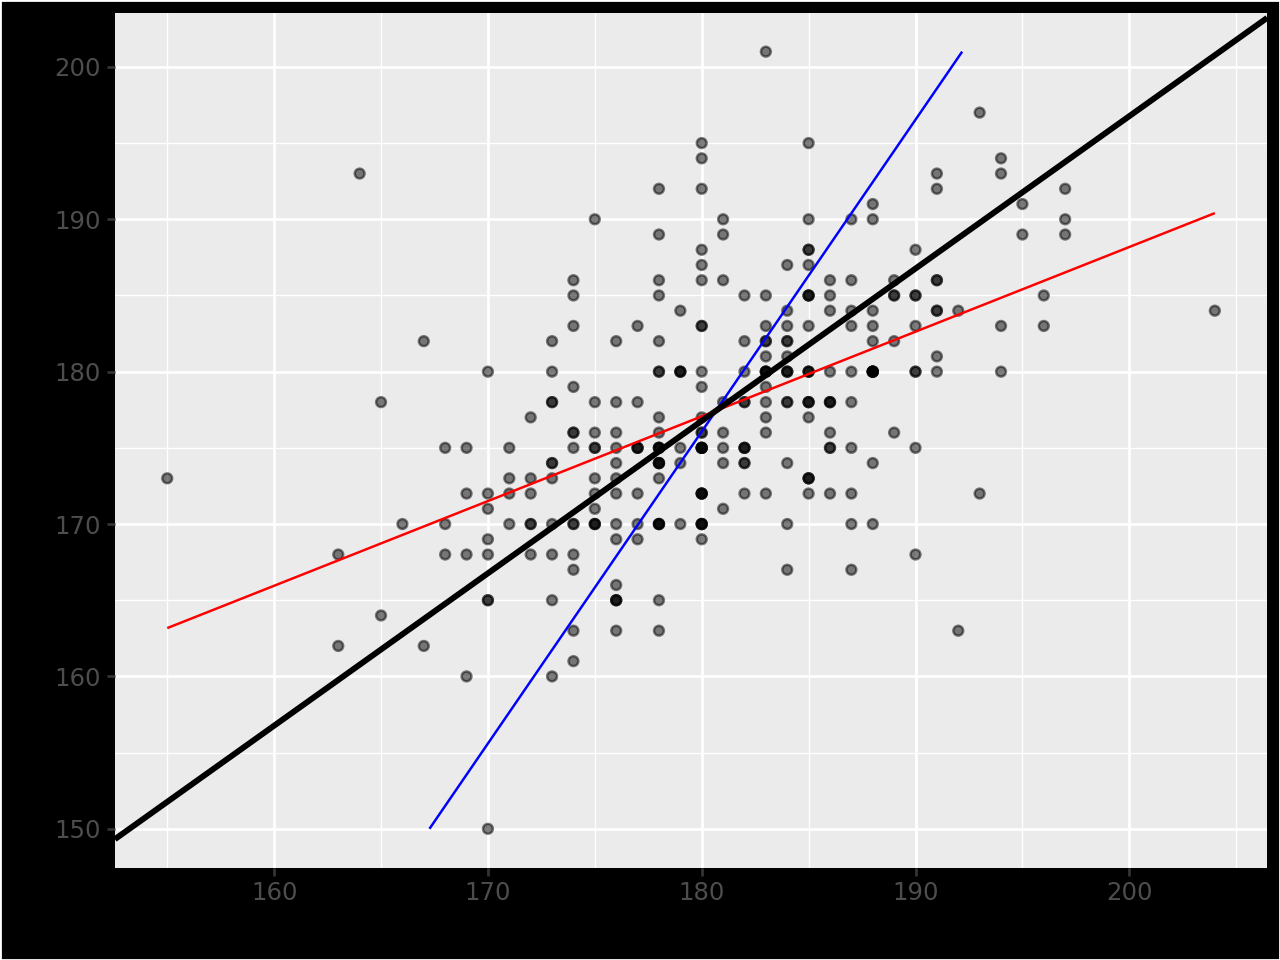

In [81]:
from sklearn.decomposition import PCA
from sklearn.preprocessing import StandardScaler

scaler = StandardScaler()

subset_males = males[['height', 'father']].dropna()
males_scaled = scaler.fit_transform(subset_males)
pca_males = PCA()
pca_males.fit(males_scaled)
components = pca_males.components_
ux, uy = components[0]

m = uy / ux
xbar, ybar = subset_males.mean(axis=0)
b = ybar - m * xbar
(
ggplot(males, aes(x='height', y='father'))
+ geom_point(alpha=0.5)
+ geom_line(aes(x='predicted_student_height', y='father'), color='blue')
+ geom_line(aes(x='height', y='predicted_father_height'), color='red')
+ geom_abline(
    slope=m,
    intercept=b,
    color='black',
    size=1.2
)
)

# As we can see the 2-dimensional PCA takes into account the orthogonal distance
# from points as linear regression simply calculates the two different lines,
# one according to the vertical difference and the other according to the horizontal difference.



5. For the model predicting each male height given the father’s height, check the plot of the residual
vs the predicted values and the Q-Q plot of the residuals. Do these plots provide evidence against the
assumptions of linear regression?

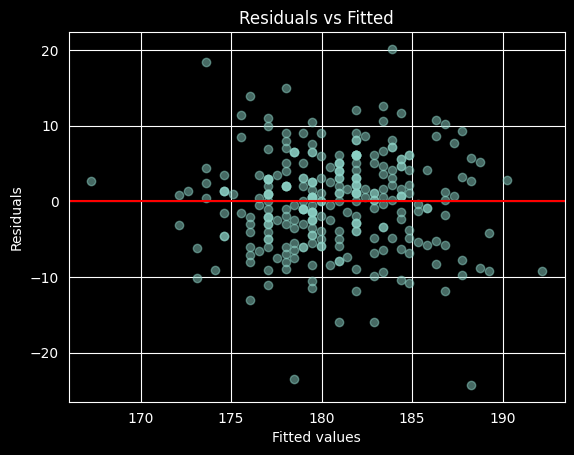

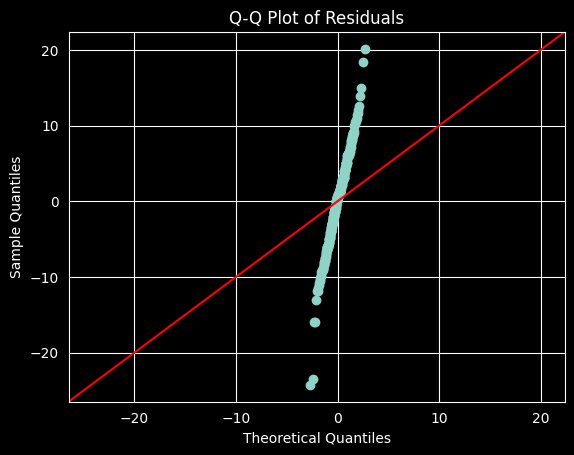

In [82]:
import matplotlib.pyplot as plt
import statsmodels.api as sm

plt.scatter(fit1.fittedvalues, fit1.resid, alpha=0.5)
plt.axhline(0, color='red')
plt.xlabel("Fitted values")
plt.ylabel("Residuals")
plt.title("Residuals vs Fitted")
plt.show()


sm.qqplot(fit1.resid, line='45')
plt.title("Q-Q Plot of Residuals")
plt.show()

We seem to find that there is no significant correlation here as R^2 is almost 0. Residuals seem to not be well approximated by a normal distribution. The father's height seems to provide little explanatory power.